# Projeto 1 - Testes de Hipóteses em Saúde: Segurança de Fármacos

Disciplina: ESTATÍSTICAS APLICADAS À COMPUTAÇÃO

Professor: Paulo Ribeiro

Aluno(s):
- AïCHA NACAMBO
- ARTHUR CORDEIRO

Data: 13/06/2026

## Introdução

A empresa farmacêutica GlobalXYZ disponibilizou dados de um ensaio clínico randomizado contendo informações sobre participantes submetidos a um tratamento medicamentoso (Drug) ou placebo.

O objetivo deste estudo é investigar possíveis diferenças entre os grupos quanto à ocorrência de efeitos adversos, quantidade de efeitos adversos e distribuição das idades dos participantes, utilizando testes estatísticos de hipóteses.

## Objetivos

Este projeto busca responder às seguintes questões:

1. A proporção de indivíduos com efeitos adversos difere entre os grupos Drug e Placebo?
2. O número de efeitos adversos está associado ao tratamento recebido?
3. Existe diferença significativa entre as idades dos participantes dos grupos Drug e Placebo?

In [129]:
import pandas as pd

from scipy.stats import chi2_contingency
from scipy.stats import mannwhitneyu

import seaborn as sns
import matplotlib.pyplot as plt

In [130]:
df = pd.read_csv("drug_safety.csv")

df[["sex", "trx", "adverse_effects"]] = df[["sex", "trx", "adverse_effects"]].astype("category")

df.head()

,age,sex,trx,week,wbc,rbc,adverse_effects,num_effects
0,62,male,Drug,0,7.3,5.1,No,0
1,62,male,Drug,1,NaN,NaN,No,0
2,62,male,Drug,12,5.6,5.0,No,0
3,62,male,Drug,16,NaN,NaN,No,0
4,62,male,Drug,2,6.6,5.1,No,0


In [131]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 16103 entries, 0 to 16102
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype   
---  ------           --------------  -----   
 0   age              16103 non-null  int64   
 1   sex              16103 non-null  category
 2   trx              16103 non-null  category
 3   week             16103 non-null  int64   
 4   wbc              9128 non-null   float64 
 5   rbc              9127 non-null   float64 
 6   adverse_effects  16103 non-null  category
 7   num_effects      16103 non-null  int64   
dtypes: category(3), float64(2), int64(3)
memory usage: 676.4 KB


O conjunto de dados contém 16.103 observações e 8 variáveis. Não foram identificados valores ausentes nas variáveis utilizadas nas análises principais (age, trx, adverse_effects e num_effects). As variáveis laboratoriais wbc e rbc apresentam valores faltantes, porém não serão utilizadas nos testes de hipóteses propostos neste projeto.

In [132]:
df.isnull().sum()

age                   0
sex                   0
trx                   0
week                  0
wbc                6975
rbc                6976
adverse_effects       0
num_effects           0
dtype: int64

Foi realizada a verificação de valores ausentes para garantir a qualidade dos dados.

In [133]:
df.describe().round(2)

,age,week,wbc,rbc,num_effects
count,16103.00,16103.00,9128.00,9127.00,16103.00
mean,64.12,7.74,7.34,4.67,0.10
std,8.78,6.94,2.00,0.46,0.32
min,39.00,0.00,1.80,2.10,0.00
25%,58.00,1.00,6.00,4.40,0.00
50%,65.00,4.00,7.10,4.70,0.00
75%,71.00,12.00,8.40,5.00,0.00
max,84.00,20.00,26.50,7.60,3.00


As estatísticas descritivas permitem observar a distribuição inicial das variáveis numéricas.

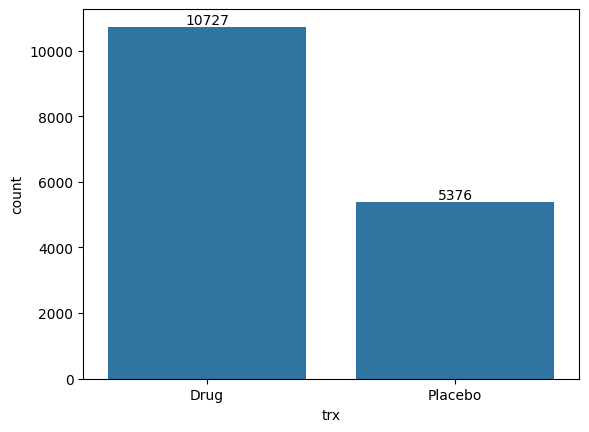

In [134]:
# Questao 1

ax = sns.countplot(data=df, x="trx")

for container in ax.containers:
    ax.bar_label(container)

plt.show()

# Aqui está a distribuição dos participantes entre os grupos Drug e Placebo.


Hipoteses

H0: A proporção de efeitos adversos é igual nos grupos Drug e Placebo.

H1: A proporção de efeitos adversos é diferente nos grupos Drug e Placebo.

In [135]:
pd.crosstab(df["trx"], df["adverse_effects"])

adverse_effects,No,Yes
trx,,
Drug,9703,1024
Placebo,4864,512


**Teste Z para Duas Proporções**

In [147]:
from statsmodels.stats.proportion import proportions_ztest

successes = [1024, 512]
totals = [10727, 5376]

z_stat, two_sample_p_value = proportions_ztest(
    count=successes,
    nobs=totals
)

print(z_stat.round(4))
print(two_sample_p_value.round(4))

0.0452
0.9639


Foi realizado um teste Z para comparação de duas proporções entre os grupos Drug e Placebo. O teste produziu um valor-p de 0,9639, muito superior ao nível de significância de 0,0452. Portanto, não há evidências estatísticas de que a proporção de efeitos adversos seja diferente entre os dois grupos. 

Os resultados sugerem que o medicamento e o placebo apresentaram taxas semelhantes de efeitos adversos.

Questão 2

Hipóteses:

H0: num_effects e trx são independentes.

H1: Existe associação entre num_effects e trx.

In [137]:
table = pd.crosstab(df['num_effects'], df['trx'])
table

trx,Drug,Placebo
num_effects,,
0,9703,4864
1,956,486
2,63,25
3,5,1


**Teste de independência qui-quadrado**

In [146]:
chi2, num_effects_p_value, dof, expected = chi2_contingency(table)

print(chi2.round(4))
print(num_effects_p_value.round(4))

1.7996
0.615


Foi realizado um teste de independência qui-quadrado para verificar se o número de efeitos adversos (num_effects) está associado ao grupo de tratamento (trx). O teste resultou em χ² = 1,7996 e p-value = 0,6150. 

Como o valor-p é maior que 0,05, não há evidências estatísticas para rejeitar a hipótese nula. Portanto, conclui-se que o número de efeitos adversos observados é independente do grupo de tratamento, não havendo associação significativa entre o medicamento e a quantidade de efeitos adversos.

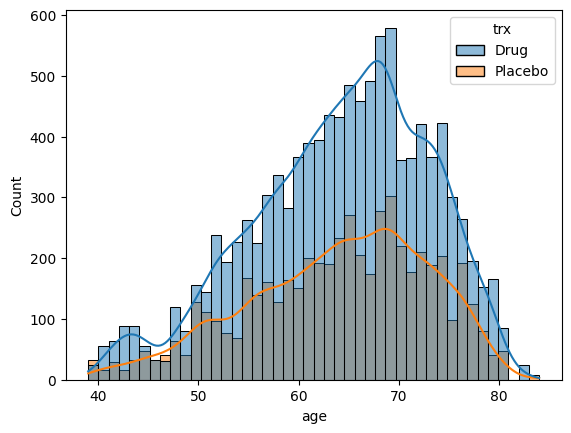

In [139]:
# Questao 3

sns.histplot(
    data=df,
    x="age",
    hue="trx",
    kde=True
)
plt.show()

O histograma indica que a distribuição das idades não é perfeitamente normal. Por esse motivo vamos utilizar o teste não paramétrico de Mann-Whitney.

H0: Não existe diferença entre as idades dos grupos.

H1: Existe diferença entre as idades dos grupos.

**Teste Mann-Whitney**

In [153]:
drug_age = df[df['trx'] == 'Drug']['age']
placebo_age = df[df['trx'] == 'Placebo']['age']

stat, age_group_effects_p_value = mannwhitneyu(
    drug_age,
    placebo_age,
    alternative='two-sided'
)

print(stat.round(3))
print(age_group_effects_p_value.round(4))

29149339.5
0.257


p = 0,2570

Como: 0,2570 > 0,05 não rejeitamos H₀.

Isso significa que uma diferença de idades como a observada pode acontecer com relativa facilidade apenas por variação aleatória entre as amostras.

Portanto:
Não há evidências estatísticas de que as idades dos participantes sejam diferentes entre os grupos Drug e Placebo.

## Conclusão

Foram realizados três testes estatísticos para avaliar possíveis diferenças entre os grupos Drug e Placebo.

- O teste Z para duas proporções indicou que a frequência de efeitos adversos não difere significativamente entre os grupos (p = 0,9639).

- O teste Qui-Quadrado mostrou que o número de efeitos adversos é independente do grupo de tratamento (p = 0,6150). 

- Por fim, o teste de Mann-Whitney revelou que não há diferença significativa entre as idades dos participantes dos dois grupos (p = 0,2570).

Dessa forma, não foram encontradas evidências estatísticas de que o medicamento tenha aumentado a ocorrência de efeitos adversos em relação ao placebo, e os grupos apresentaram perfis etários semelhantes.